# ABM

The provided notebook contains a basic implementation of a model of political party competition in relation to alternative voting systems. The model consists of political parties and districts. Political parties have a policy position in a 2-D continuous space.

A political party runs candidates in all districts sampled from a 2-D normal distribution centered on its current policy position. Depending on how well the elections go, the party updates its policy position and runs new candidates in the districts it has lost. The party always keeps its successful candidates.

A district has a population of voters. There are three distinct subpopulations, each with its own mean policy position. The districts differ in how many population members are sampled from each subpopulation. Given the candidates run by each party in their district, the district members vote. In the current implementation, there is no change in the policy position of the population.

The model comes with 3 different voting systems:

a) First past the post (plurality vote)

b) Majority vote where the worst performing candidate is dropped each round until a candidate secures more than 50% of the vote

c) Borda count, rather than vote for a preferred single candidate, all population members rank order their candidate with 0 points for the most preferred candidate. Next, the total score for each candidate is calculated by summing the points across the population. The candidate with the lowest total score wins.

The model aims to explore the behaviour of political parties as expressed by how they move through policy space across these different voting systems. The model is inspired by ongoing discussions in the UK and various states of the US about changing their voting system.

The provided notebook contains the implementation of the complete model, but the default rule of how parties update their policy position is not interesting. In the provided version, parties follow a so-called Stickler rule. That is, political parties have a fixed policy position and never change this position. They only run new candidates in those districts they have lost, but these are sampled from the same 2-D normal distribution centered on a static policy position.

1. Change the behaviour of the party from the stickler rule to a combination of the aggregator rule and the vote seeker rule. The aggregator rule holds that the new policy position of the party is the mean of the policy positions of the candidates that have won for that party. The agents follow this rule if they have won any seats. If a party does not win any seats, it follows a vote-seeker rule. The vote-seeker rule states that a party updates its policy position by moving towards the policy position of the largest party. Assume that they do this by moving 5% towards the biggest party on both dimensions of the policy space.

- (20/100) Sketch a flowchart or provide in pseudo-code a conceptual description of the modified step method for the political party

- (30/100) Implement the step method. For validation purposes, the figure below gives you a sense of the dynamics the model produces. The necessary code to create this visual is included in the notebook.

Figure 1 Indicative results for seed 15, and plurality voting. The left-hand plot shows the movement of the political parties through policy space. The blue lines are a gaussian kernel density estimate of the policy position density of the population. The top right-hand plot shows the number of seats over time. The bottom left-hand plot shows the vote share.

2. (20/100) The current implementation of the model treats the population as static. There has been some work, however, that suggests that people are open to moving to different geographically neighbouring districts if this improves the alignment between their policy position and the policy position of the candidate typically selected in that other district. One example of this type of work is the so-called Tiebout model.

Provide a detailed conceptual description of how you would modify the provided model to bring in this additional dynamic of the population potentially moving to geographically neighbouring districts based on the kind of candidate being elected in these districts. Consider potential modifications to the agents in the model, the space, scheduling, or step methods.

The model aims to explore the impact of voting systems on the behaviour of political parties. Explore the behaviour of the model for the three provided voting systems.

If you struggled to answer question 1, continue with the originally provided model.

(15/100) Implement the code necessary for performing the described set of experiments

(10/100) Provide a clear visualization of how the model's behaviour changes across the three voting systems.

(5/100) Describe and explain the changes in behavior as shown in response to question 3B.

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns


from collections import Counter
from scipy.spatial.distance import cdist

from mesa import Model, Agent
from mesa.datacollection import DataCollector
from mesa.experimental.continuous_space import ContinuousSpace, ContinuousSpaceAgent

"""
District-level election execution.

This method runs one election for this district at each model tick. It collects one
candidate from every party for this district and passes the district population plus
candidates to `self.vote(...)` (the selected voting rule, e.g. plurality/majority/Borda).

Important: voters are not Mesa agents in this model. `self.population` is a NumPy array
of voter policy positions, and all votes are computed vectorially in one call. The actual
winner/total vote calculation is implemented in the vote-rule functions, while this method
stores the returned district winner and party totals in model-level result arrays.

X,Y positions represent closeness to a policy stance of a candidate
"""


def plurality_vote(population, candidates, parties):
    # calculate distances to all candidates
    distances = cdist(population, candidates)

    # depending on vote scheme determine who wins
    winners = np.argmin(distances, axis=1)
    unique, counts = np.unique(winners, return_counts=True)

    votes_per_party = np.zeros(len(parties))
    for party_id, votes in zip(unique, counts):
        votes_per_party[party_id] = votes

    winning_party_index = unique[counts.argmax()]
    return parties[winning_party_index], votes_per_party


def borda_count(population, candidates, parties):
    # calculate distances to all candidates
    distances = cdist(population, candidates)
    
    # handles ties poorly but is order of magnitude faster
    rank = np.argsort(
        np.argsort(distances, axis=1), axis=1
    )  
    # rank = sp.stats.rankdata(distances, method='min', axis=1) # as per olympics
    scores = rank.sum(axis=0)
    winning_party_index = np.argmin(scores)
    return parties[winning_party_index], scores


def majority_vote(population, candidates, parties):
    distances = cdist(population, candidates)
    parties = np.asarray(parties)

    # vote share in first round
    winners = np.argmin(distances, axis=1)
    unique, counts = np.unique(winners, return_counts=True)

    votes_per_party = np.zeros(len(parties))
    for party_id, votes in zip(unique, counts):
        votes_per_party[party_id] = votes

    # determine the actual winner
    while True:
        ranking = np.argsort(np.argsort(distances, axis=1))
        counts = np.sum(ranking == 0, axis=0)

        if np.any(counts >= 0.5 * population.shape[0]):
            return parties[counts.argmax()], votes_per_party
        else:
            # crude way of avoiding ties
            remaining_candidates = np.ones(parties.shape, dtype=bool)
            remaining_candidates[np.argmin(counts)] = False
            distances = distances[:, remaining_candidates]
            parties = parties[remaining_candidates]


class VotingModel(Model):
    """Voting model class

    Args:
        n_districts : int
        n_parties : int
        seed : int, optional
        vote_system : callable, optional

    Note that the entire implementation is based on numpy rather than pandas. The
    pure numpy implementation is more then an order of magnitude faster than an
    equivalent pandas implementation.

    """
    def __init__(self, n_districts: int, n_parties: int, seed=None, vote_system=plurality_vote):
        super().__init__(seed=seed)
        self.n_districts = n_districts
        self.n_parties = n_parties

        self.space = ContinuousSpace([[-2, 2],[-2, 2]], torus=False, random=self.random)

        # sub population policy profile means
        # hard coded assumption of 3 sub populations
        self.profiles = np.asarray([[0.25, 0.25], [0.50, 0.75], [0.8, 0.33]])

        # district are heterogeneous with respect to how large each subpopulation is
        district_compositions = self.rng.random(
            size=(n_districts, self.profiles.shape[0])
        )
        district_compositions = (
            district_compositions / np.sum(district_compositions, axis=1)[:, np.newaxis]
        )

        # create districts
        for i, composition in enumerate(district_compositions):
            district = District(self, composition, i, vote_system=vote_system)

        # create parties
        for i in range(n_parties):
            profile = self.random.choices(self.profiles)
            position = self.rng.normal(profile, (0.15,) * 2, size=(1, 2))[0]
            party = Party(self, position, i, n_districts)

        self.seats = np.zeros((n_parties,))
        self.datacollector = DataCollector(
            agenttype_reporters={Party:{
                "x": "x",
                "y": "y",
                "seats": "seats",
                "voteshare": "voteshare",}
            },
        )
        self.election_results = np.zeros(self.n_districts, dtype=object)
        self.votes_per_district = np.zeros(
            (self.n_districts, self.n_parties),
        )
        self.voteshare = np.zeros((self.n_districts,))
        self.datacollector.collect(self)
        
    def get_population(self):
        return np.concatenate([d.population for d in self.agents_by_type[District]], axis=0)

    def step(self):
        """
        Run one step of the model.
        """
        # let districts vote
        self.agents_by_type[District].do("step")
        
        # update model level attributes
        self.voteshare = (
            self.votes_per_district.sum(axis=0) / self.votes_per_district.sum()
        )

        # let parties update their policy position
        self.agents_by_type[Party].do("step")

        self.datacollector.collect(self)


class District(Agent):
    """District agent

    Parameters
    ----------
    unique_id : int
    model : VotingModel instance
    composition : tuple
    i_district : int
                 index of this district in model.election_results,
                 model.votes_per_district, and party.candidates
    vote_system : callable, option


    i_district is used as part of the numpy implementation

    """

    std = [0.1, 0.1]
    population_size = 100

    def __init__(self, model, composition, i_district, vote_system=plurality_vote):
        super().__init__(model)
        self.composition = composition
        self.vote = vote_system #voting pattern of agents depends on voting system and is called when initiatin the function
        self.elected_party = None
        self.i_district = i_district

        # setup voters
        n_per_subpopulation = np.round(self.composition * self.population_size).astype(int)

        voters = []
        for n, profile in zip(n_per_subpopulation, model.profiles):
            voters.append(self.rng.normal(profile, self.std, size=(n, 2)))
        self.population = np.concatenate(voters, axis=0)

    def step(self):
        parties, candidates = zip(
            *[
                (party, party.get_candidate_for_district(self.i_district))
                for party in self.model.agents_by_type[Party]
            ]
        )
        candidates = np.asarray(candidates)

        winning_party, votes_per_party = self.vote(self.population, candidates, parties)
        self.model.election_results[self.i_district] = winning_party
        self.model.votes_per_district[self.i_district, :] = votes_per_party


class Party(ContinuousSpaceAgent):
    """Party agent

    Parameters
    ----------
    unique_id : int
    model : VotingModel instance
    policy_position : 2 tuple
    i_party : int
              index of party in global attributes
    n_districts : int
                  number of districts


    """

    std = [0.025, 0.025]  # std for policy position of candidates

    @property
    def x(self):
        return self.pos[0]

    @property
    def y(self):
        return self.pos[1]

    @property
    def seats(self):
        return self._seats

    @seats.setter
    def seats(self, value):
        self._seats = value

    def __init__(self, model, policy_position, i_party, n_districts):
        super().__init__(model.space, model)
        self.position =  policy_position
        self.i_party = i_party
        self.candidates = self.rng.normal(
            self.pos, self.std, size=(n_districts, 2)
        )
        self.seats = 0
        self.seat_change = 0
        self.voteshare = 0

    def get_candidate_for_district(self, i_district):
        return self.candidates[i_district, :]

    def get_election_results(self):
        self.election_results = self.model.election_results
        n_seats = np.sum(self.election_results == self)

        self.seat_change = n_seats - self.seats
        self.seats = n_seats
        self.voteshare = self.model.voteshare[self.i_party]

    def step(self):
        # I need to know where I have won and lost
        self.get_election_results()

        won = (self.election_results == self)
        lost = (won == False)

        # generate new candidates for lost districts
        self.candidates[lost] = self.rng.normal(
            self.pos, self.std, size=(lost.sum(), 2)
        )



In [2]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

def plot_single_run(model):
    agent_data = model.datacollector.get_agenttype_vars_dataframe(Party)
    pop = model.get_population()
    
    sns.set_style('white')

    fig = plt.figure(constrained_layout=True)
    gs = GridSpec(2,4, figure=fig)

    ax1 = fig.add_subplot(gs[:, 0:2]) # policy space
    ax1.set_xlim(xmin=-0.25, xmax=1.25)
    ax1.set_ylim(ymin=-0.25, ymax=1.25)

    ax2 = fig.add_subplot(gs[0, 2:]) # number of seats
    ax3 = fig.add_subplot(gs[1, 2:]) # share of the overal vote

    sns.kdeplot(x=pop[:, 0], y=pop[:, 1], ax=ax1)
    for c, (_, party_data) in zip(sns.color_palette(), agent_data.groupby('AgentID')):
        x = party_data.x.values
        y = party_data.y.values
    
        ax1.plot(x, y, c=c )
        ax1.scatter(x[-1], y[-1], color=c)
        ax2.plot(party_data.seats.values, c=c)
        ax3.plot(party_data.voteshare.values, c=c)
        
    ax1.set_title('policy space')
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    ax2.set_ylabel('seats won')
    ax2.set_xlabel('ticks')

    ax3.set_ylabel('vote share')
    ax3.set_xlabel('ticks')
    ax3.set_ylim(ymin=0, ymax=1)
    
    # create a custom figure level legend
    parties = model.agents_by_type[Party]
    handles = [Line2D([0,0], [1,1], c=c) for _, c in zip(parties, sns.color_palette())]
    labels = [f'party {i}' for i in range(len(parties))]
    fig.legend(handles, labels, bbox_to_anchor=[1.1, 1])
    
    for ax in [ax2, ax3]:
        sns.despine(ax=ax)


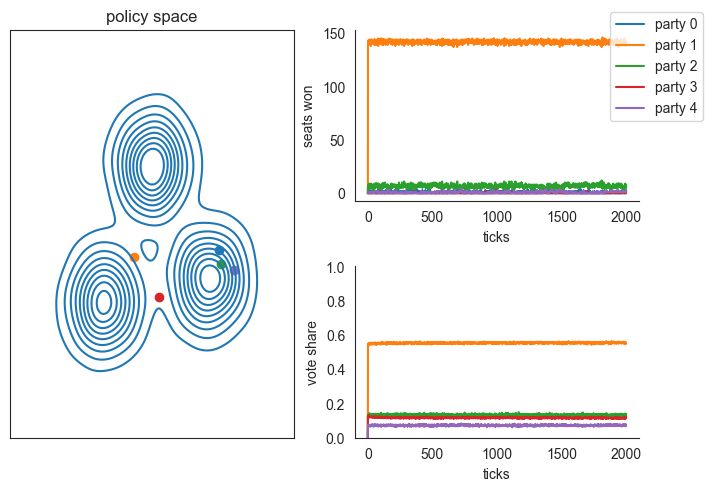

In [5]:
seed = 15
original_model = VotingModel(n_districts=150, n_parties=5, seed=seed, vote_system=plurality_vote)
for _ in range(1000):
    model.step()
plot_single_run(model)
plt.show()

### 1. Change policy update pattern
Implemented and visualized the modified step method for the political party. The parties now follow a combination of the aggregator rule and the vote seeker rule. The left-hand plot shows the movement of the political parties through policy space. The blue lines are a gaussian kernel density estimate of the policy position density of the population. The top right-hand plot shows the number of seats over time. The bottom left-hand plot shows the vote share. The flowchart is attached in the ipad freeform sketching app.


In [6]:
def _party_step_agg_vote_seeker(self):
    self.get_election_results()

    won = (self.election_results == self)
    lost = ~won

    if won.any():
        # Aggregator rule: move to mean of this party's winning candidates.
        new_pos = self.candidates[won].mean(axis=0)
    else:
        # Vote-seeker rule: move 5% toward largest party in policy space.
        parties = list(self.model.agents_by_type[Party])
        largest = max(parties, key=lambda p: (p.seats, p.voteshare, -p.i_party))
        new_pos = self.pos + 0.05 * (largest.pos - self.pos)

    # Update party policy position.
    self.position = new_pos

    # Keep winning candidates; only redraw candidates in lost districts.
    if lost.any():
        self.candidates[lost] = self.rng.normal(self.pos, self.std, size=(lost.sum(), 2))


# Monkey-patch without rewriting the model
Party.step = _party_step_agg_vote_seeker

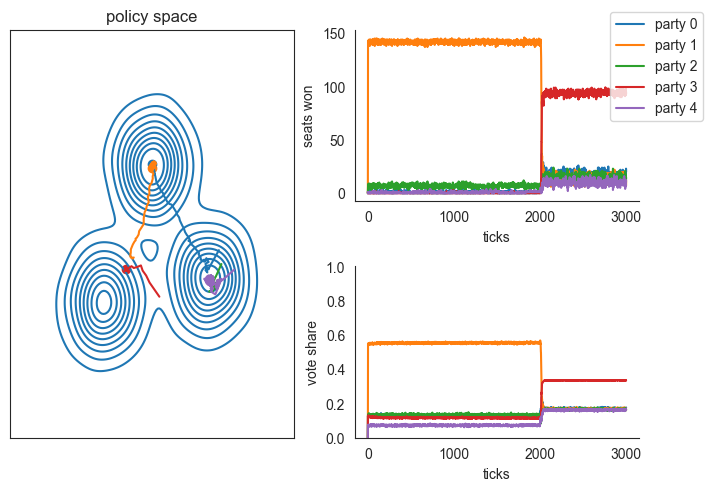

In [7]:
seed = 15
original_model = VotingModel(n_districts=150, n_parties=5, seed=seed, vote_system=plurality_vote)
for _ in range(1000):
    model.step()
plot_single_run(model)
plt.show()

### 2. Tiebout model
In this version, if the population is unhappy with the results in its district(i.e., the distance is larger than a certain treshold),it can move to another district whose election winner stand closer to the population's policy position. To select a district that is geographically clsoe event though we do not have geographcial coordinates, I propose the use of a certain radius of neighbours, so x+2 around the current district where the population can move. The population will move to the district with the closest policy position of the winning candidate within this radius. If there are no districts with a closer winning candidate, the population will stay in its current district. This way, we can model the movement of the population based on their satisfaction with the election results in their current district and their willingness to move to a nearby district with a more favorable outcome. (conceptual explanation).

To implement this dynamic, especially if we want to avoid empty districts, we need a new agent type, the population agent. This agent will represent a group of voters in a district and will have attributes such as their policy position and the district they belong to. The population agent will have a step method that checks the election results in their current district and decides whether to move to a neighboring district based on the distance to the winning candidate's policy position and their tolerance treshold. The model's step method will need to be modified to include the population agents' step method, and we will also need to implement a way for the population agents to move between districts. The district agent also needs to be updated, to now call on the information of the popualtion agents assigned to it, rather than the static population attribute. This way, we can model the dynamic movement of the population in response to election results and their impact on the political parties' strategies and policy positions over time.

### Question 3 experiment pipeline

** Goal **
- Compare party-system behavior under the three voting rules:
  1. `plurality_vote`
  2. `majority_vote`
  3. `borda_count`

**Approach**
- Run multiple stochastic replications per voting rule.
- Record time-series indicators that summarize competition and concentration.
- Plot both dynamic trajectories and final cross-run distributions.


**Assumption**
- `Party.step` has already been patched to the aggregator + vote-seeker rule

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist

"""
    Voting-rule registry and summary metrics.
"""

VOTING_SYSTEMS = {
    "Plurality": plurality_vote,
    "Majority runoff": majority_vote,
    "Borda count": borda_count,
}


def run_experiments(
        n_runs=20,
        n_steps=300,
        n_districts=150,
        n_parties=5,
        base_seed=200,
):
    """
    Run replicated simulations for each voting system and collect indicators.

    Indicators collected each tick:
    - enp_seats: effective number of parties in seats
    - enp_votes: effective number of parties in votes
    - max_seat_share: seat share of largest party
    - max_vote_share: vote share of largest party
    - policy_dispersion: mean pairwise distance among party policy positions

    Returns
    -------
    exp_df : pandas.DataFrame
        Long-format panel of run/tick-level indicators.
    rep_models : dict[str, VotingModel]
        One representative fitted model per voting system (useful for trajectory plots).
    """
    rows = []
    rep_models = {}

    for system_name, vote_fn in VOTING_SYSTEMS.items():
        for run in range(n_runs):
            seed = base_seed + run
            model = VotingModel(
                n_districts=n_districts,
                n_parties=n_parties,
                seed=seed,
                vote_system=vote_fn,
            )
            prev_positions = None  # track previous tick to compute movement

            # Keep one model per system for qualitative path visualization.
            if run == 0:
                rep_models[system_name] = model

            # Simulate and record aggregate party-system indicators over time.
            for t in range(n_steps):
                model.step()
                parties = list(model.agents_by_type[Party])

                seat_counts = np.array([p.seats for p in parties], dtype=float)
                seat_shares = seat_counts / n_districts
                vote_shares = np.array([p.voteshare for p in parties], dtype=float)

                positions = np.array([p.pos for p in parties], dtype=float)
                policy_dispersion = pdist(positions).mean() if len(positions) > 1 else 0.

                # Movement metrics (party-identity agnostic)
                if prev_positions is None:
                    mean_step_movement = np.nan
                    movement_volatility = np.nan
                else:
                    step_sizes = np.linalg.norm(positions - prev_positions, axis=1)
                    mean_step_movement = step_sizes.mean()
                    movement_volatility = step_sizes.std() #movement_volatility is the standard deviation of those step sizes across parties at that tick.

                centroid = positions.mean(axis=0)
                #compute each party’s distance to the average  position of all parties and average those distances.
                mean_distance_to_centroid = np.linalg.norm(positions - centroid, axis=1).mean()

                prev_positions = positions.copy()

                rows.append(
                    {
                        "system": system_name,
                        "run": run,
                        "tick": t + 1,
                        "max_seat_share": seat_shares.max(),
                        "max_vote_share": vote_shares.max(),
                        "policy_dispersion": policy_dispersion,
                        "mean_step_movement": mean_step_movement,
                        "movement_volatility": movement_volatility,
                        "mean_distance_to_centroid": mean_distance_to_centroid,
                    }
                )

    exp_df = pd.DataFrame(rows)
    return exp_df, rep_models

In [21]:
"""
Execute the full experiment set for Question 3(a).
"""

exp_df, rep_models = run_experiments(
    n_runs=20,
    n_steps=300,
    n_districts=150,
    n_parties=5,
    base_seed=200,
)

exp_df.head()

,system,run,tick,max_seat_share,max_vote_share,policy_dispersion,mean_step_movement,movement_volatility,mean_distance_to_centroid
0,Plurality,0,1,0.426667,0.249567,0.354151,NaN,NaN,0.239216
1,Plurality,0,2,0.453333,0.253500,0.360039,0.010349,0.004586,0.242152
2,Plurality,0,3,0.440000,0.258634,0.361281,0.011203,0.008226,0.241116
3,Plurality,0,4,0.480000,0.263635,0.364284,0.012996,0.009200,0.242337
4,Plurality,0,5,0.486667,0.268236,0.364086,0.009457,0.004710,0.241155


/var/folders/hr/5k7_qdqs61lfllhj97j5fy8w0000gn/T/ipykernel_3531/1870079447.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hr/5k7_qdqs61lfllhj97j5fy8w0000gn/T/ipykernel_3531/1870079447.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hr/5k7_qdqs61lfllhj97j5fy8w0000gn/T/ipykernel_3531/1870079447.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/hr/5k7_qdqs61lfllhj97j5fy8w0000gn/T/ipykernel_3531/1870079447.py:91: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0

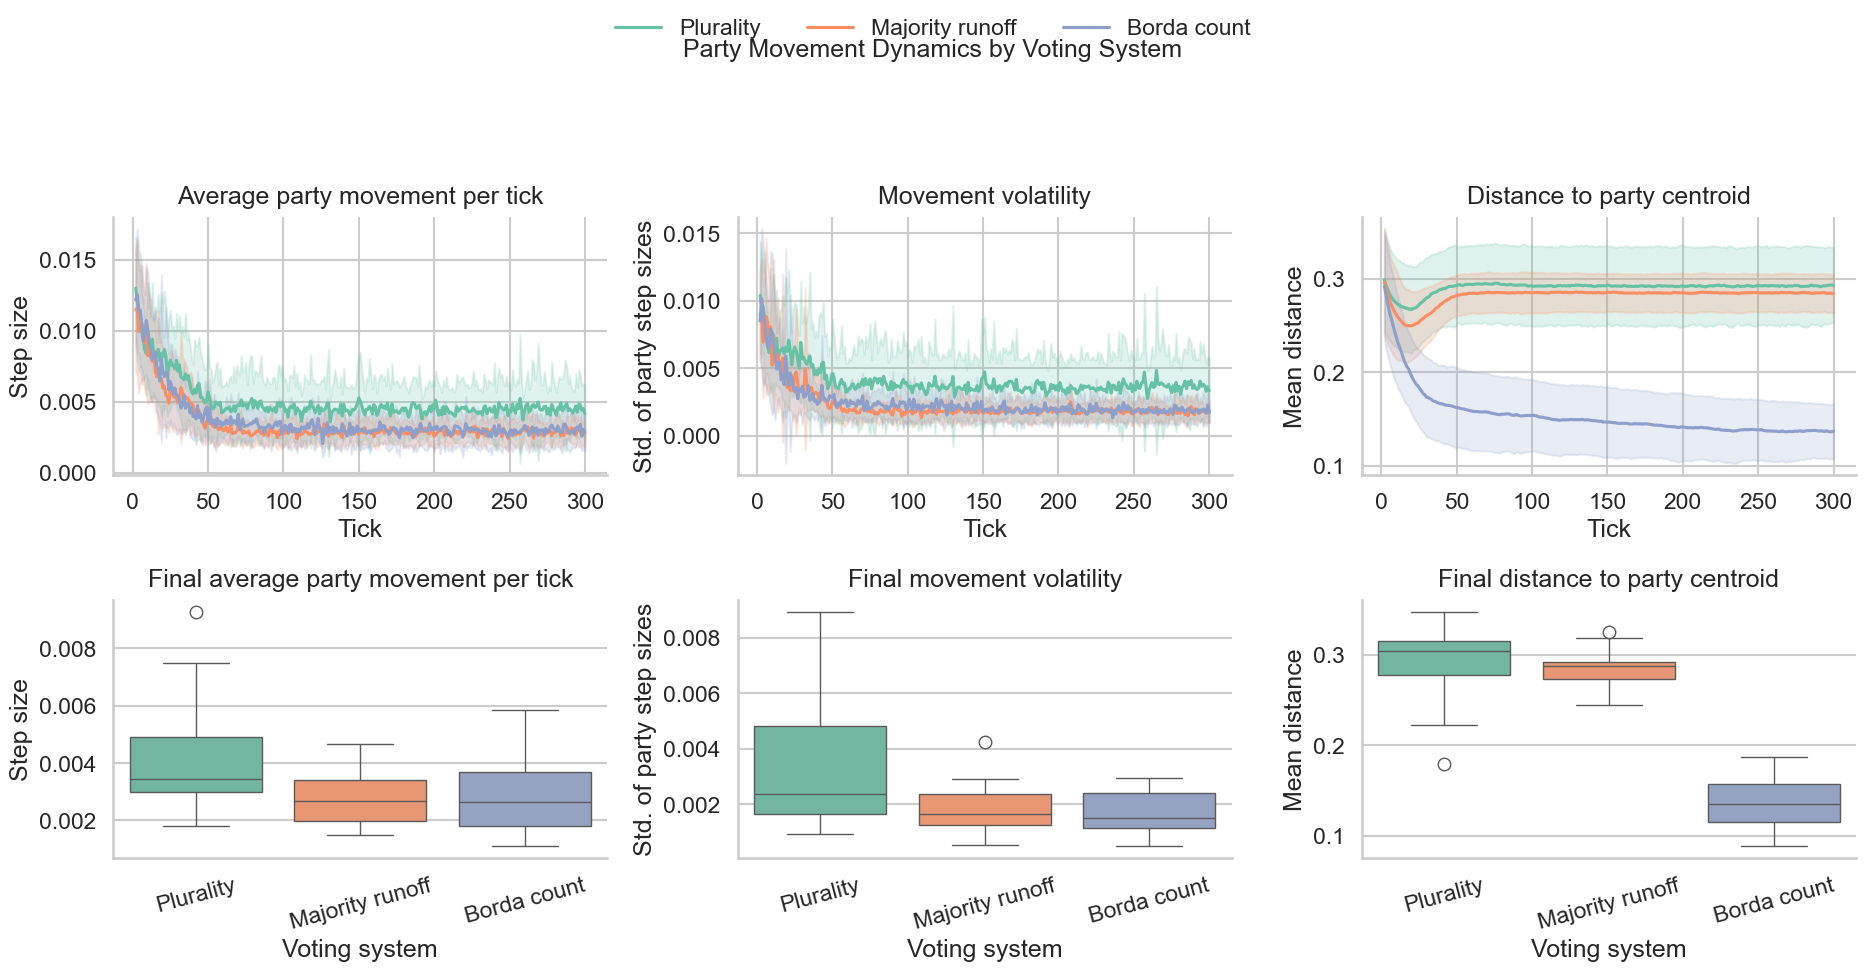

In [19]:

def plot_movement_dynamics(exp_df):
    # High-level plotting configuration for readability and consistency.
    sns.set_theme(style="whitegrid", context="talk")

    metrics = [
        ("mean_step_movement", "Average party movement per tick", "Step size"),
        ("movement_volatility", "Movement volatility", "Std. of party step sizes"),
        ("mean_distance_to_centroid", "Distance to party centroid", "Mean distance"),
    ]

    # Keep system order stable (matches your registry if available).
    if "VOTING_SYSTEMS" in globals():
        system_order = list(VOTING_SYSTEMS.keys())
    else:
        system_order = sorted(exp_df["system"].unique())

    palette = sns.color_palette("Set2", n_colors=len(system_order))
    color_map = dict(zip(system_order, palette))

    # Ignore first-tick NaNs introduced by movement calculation.
    plot_df = exp_df.copy()
    for m, _, _ in metrics:
        plot_df = plot_df[~plot_df[m].isna()]

    # Final snapshot per run for distribution comparison.
    final_df = (
        plot_df.sort_values("tick")
        .groupby(["system", "run"], as_index=False)
        .tail(1)
    )

    fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)

    # --- Top row: dynamic behavior over time ---
    for i, (metric, title, ylabel) in enumerate(metrics):
        ax = axes[0, i]
        sns.lineplot(
            data=plot_df,
            x="tick",
            y=metric,
            hue="system",
            hue_order=system_order,
            palette=color_map,
            estimator="mean",
            errorbar="sd",
            ax=ax,
            legend=(i == 0),  # single legend for top row
        )
        ax.set_title(title, pad=10)
        ax.set_xlabel("Tick")
        ax.set_ylabel(ylabel)
        sns.despine(ax=ax)

        if i > 0 and ax.get_legend() is not None:
            ax.get_legend().remove()

    # --- Bottom row: final cross-run distributions ---
    for i, (metric, title, ylabel) in enumerate(metrics):
        ax = axes[1, i]
        sns.boxplot(
            data=final_df,
            x="system",
            y=metric,
            order=system_order,
            palette=color_map,
            ax=ax,
        )
        ax.set_title(f"Final {title.lower()}", pad=10)
        ax.set_xlabel("Voting system")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=15)
        sns.despine(ax=ax)

    # Figure-level legend outside plotting area
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if axes[0, 0].get_legend() is not None:
        axes[0, 0].get_legend().remove()

    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=len(system_order),
        frameon=False,
        bbox_to_anchor=(0.5, 0.99)
    )

    # Title below legend (still above plots)
    fig.suptitle("Party Movement Dynamics by Voting System", fontsize=18, y=0.95)

    # Reserve vertical space for legend + title
    fig.tight_layout(rect=[0, 0, 1, 0.88])

    plt.show()

# Run it
plot_movement_dynamics(exp_df)

The first insight from this plot is that over all metrics related to party behaviour the voting system that produces the largest spread of behaviours is the pluraility system. That is because with the pluralirty voitng system, a bigger mix of candidates can win every step of every run, there being no requirements for a candidate to meet a certain treshold. This means that the parties also can take up more diverse adaptations and increase the nubmer of scenarios possible for movement. Across all metrics, the most table voting system is the majority run off, always displaying the least amount of variation, which can be intuited as a smaller spread of parties can reach the 50% cutoff. We oberve that across all metrics the biggest steps are taken in all voting systems at the beginning of the model, while after around 100 ticks, the parties have found a more stable position in the policy space and take smaller steps. The distance to the centroid is also the highest at the beginning of the model, which can be intuited as the parties starting from a more dispersed position in the policy space, while over time they converge towards a more similar position. The volatility of movement is also higher at the beginning of the model, which can be intuited as the parties exploring different positions in the policy space before converging towards a more stable position. The most interesting observation relates to the Bords count, which has a significantly higher downward slope in distance to party centroid which never recovers, as opposed to the plurality and majority cut off systems. this indicates that the Borda count does not have a tendency to induce parties to get closer to the centroid of the policy space, which can be intuited as a more diverse set of parties being able to win under the Borda count, as opposed to the other two voting systems where the parties tend to converge towards a more similar position in the policy space.